# Value Function Approximation

Following various segments in Part 2 of *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [2]:
import random
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from functools import partial

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

### Gridworld

In [3]:
maze_grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 3],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [2, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
])

maze_env = GridMazeEnv(maze_grid)
maze_env

[[□ □ □ □ □ □ □ ■ G]
 [□ □ ■ □ □ □ □ ■ □]
 [S □ ■ □ □ □ □ ■ □]
 [□ □ ■ □ □ □ □ □ □]
 [□ □ □ □ □ □ □ □ □]
 [□ □ □ □ □ ■ □ □ □]]

In [4]:
def get_state_features_normalized(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """Return normalized grid coords."""
    s_features = (s[0] / (grid_shape[0] - 1), s[1] / (grid_shape[1] - 1))
    return torch.Tensor(s_features)

def get_state_features_one_hot(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """
    One-hot encoding of grid state. Equivalent to tabular representation.
    """
    H, W = grid_shape
    idx = s[0] * W + s[1]

    x = torch.zeros(H * W, dtype=torch.float32)
    x[idx] = 1.0
    return x

### Linear Function Approximation

In [5]:
class Q_VFA_Linear(nn.Module):
    def __init__(self, state_dim: int, action_dim):
        super().__init__()
        self.w = nn.Linear(state_dim, action_dim, bias=False) # taking in state feature vector, spitting out Q-value for each action
    
    def forward(self, x: torch.Tensor):
        return self.w(x)

In [6]:
def pi_epsilon_greedy(s: tuple[int, int], Q_pi: Q_VFA_Linear, epsilon: float, grid_shape: tuple[int, ...], state_features_method: Callable) -> int:
    p = np.random.random()

    if p < epsilon: # explore
        return int(np.random.randint(Q_pi.w.weight.shape[0]))
    return int(np.argmax(Q_pi(state_features_method(s, grid_shape)).detach().numpy())) # exploit

In [6]:
q_hat = Q_VFA_Linear(get_state_features_one_hot(maze_env.goal_position, maze_env.grid.shape).shape[0], maze_env.action_set.__len__())
q_hat

Q_VFA_Linear(
  (w): Linear(in_features=54, out_features=4, bias=False)
)

In [7]:
q_hat.w.weight

Parameter containing:
tensor([[-0.0792, -0.1106,  0.1169, -0.0088, -0.0558, -0.0860, -0.0609,  0.1054,
          0.1314,  0.1121, -0.1015, -0.0691, -0.0646,  0.0603, -0.0796,  0.0729,
          0.0624,  0.0818,  0.1290,  0.0171,  0.0184,  0.0327, -0.1316, -0.0175,
          0.0550, -0.0141,  0.0667,  0.1243,  0.1349,  0.0502, -0.0841,  0.0113,
          0.1222,  0.0475,  0.0561,  0.1242, -0.0489,  0.0926,  0.0045,  0.1219,
          0.1043,  0.1357,  0.0311,  0.0006,  0.0730,  0.0321,  0.0066, -0.0676,
          0.0521, -0.0832, -0.0893,  0.0852,  0.0910,  0.0929],
        [ 0.0365,  0.0671,  0.0595, -0.1334, -0.0127, -0.0253, -0.1231, -0.0848,
         -0.0821,  0.1062,  0.0057, -0.1178, -0.0199,  0.0418,  0.0308, -0.1089,
          0.1359, -0.0339, -0.1098, -0.0716, -0.0516, -0.0062,  0.0986, -0.1325,
          0.0970,  0.1195,  0.0720,  0.1230, -0.0014, -0.0953,  0.1089, -0.1171,
         -0.1237, -0.0398, -0.0607, -0.0053, -0.1084,  0.0310,  0.1163,  0.1029,
         -0.0928, -0.12

#### SARSA / TD-0

In [ ]:
def run_SARSA_VFA(
    maze_env: GridMazeEnv, 
    gamma: float, alpha: float, 
    epsilon_start: float, epsilon_min: float, epsilon_decay: float,
    num_epochs: int, warmup_epochs: int, max_steps: int,
    state_features_method: Callable,
    ) -> tuple[Q_VFA_Linear, dict]:

    grid_shape = maze_env.grid.shape
    q_hat = Q_VFA_Linear(
        state_features_method(maze_env.goal_position, grid_shape).shape[0], 
        maze_env.action_set.__len__()
        )
    optimizer = torch.optim.SGD(q_hat.parameters(), lr=alpha)
    pbar = tqdm(range(num_epochs), desc="SARSA")
    metrics = {
        "episode_lengths": []
    }

    successes = 0
    for ep_idx in pbar:

        # --- epsilon schedule ---
        if ep_idx < warmup_epochs:
            epsilon = epsilon_start
        else:
            epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** (ep_idx - warmup_epochs)))

        # --- initial state ---
        s = maze_env.reset()    

        # --- intra-episode loop ---
        episode_steps = 0
        for step in range(max_steps):
            phi_s = state_features_method(s, grid_shape) # Extract state features for s

            # --- select action and step ---
            a = pi_epsilon_greedy(s, q_hat, epsilon, grid_shape, state_features_method)
            r, s_prime, done = maze_env.step(a)

            # --- Reward adjustment for maze ---
            if done:
                r = 1.0 # Goal reward
            else:
                r = -0.01 # Step penalty

            # --- s' features and a' for SARSA ---
            phi_sp = state_features_method(s_prime, grid_shape) # Extract state features for s'
            a_prime = torch.argmax(q_hat(phi_sp)).item() # Greedy action (not epsilon-greedy) for stability. closer to expected SARSA/Q-learning hybrid

            # --- value function update ---
            prediction = q_hat(phi_s)[a] # Q(s, a)
            with torch.no_grad():
                q_next = 0.0 if done else q_hat(phi_sp)[a_prime] # Q(s', a')
                target = r + gamma * q_next # bootstrapping target: r + γ * Q(s', a')
            loss = (target - prediction) ** 2 # error term: [r + γ * Q(s', a') - Q(s, a)] ^ 2

            optimizer.zero_grad()
            loss.backward() # compute gradients backwards from loss (error term)
            optimizer.step() # update: w <- w + α * [r + γ * Q(s', a') - Q(s', a')] ^ 2 ; Note that α (alpha) here comes from the optimizer itself (lr)

            # --- housekeeping ---
            s = s_prime
            episode_steps = step + 1
            if done:
                successes += 1
                break
        
        # --- update metrics & pbar ---
        metrics["episode_lengths"].append(episode_steps)
        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=step + 1,
            epsilon=f"{epsilon:.3f}",
        )
    
    # --- return ---
    return q_hat, metrics

In [31]:
alpha = 5e-3
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_epochs = 1000
warmup_epochs = 50
max_steps = 150
state_feature_method: Callable = get_state_features_one_hot

q_hat, metrics = run_SARSA_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method)

SARSA: 100%|██████████| 1000/1000 [00:32<00:00, 30.70it/s, epsilon=0.050, steps=16, successes=770/1000]


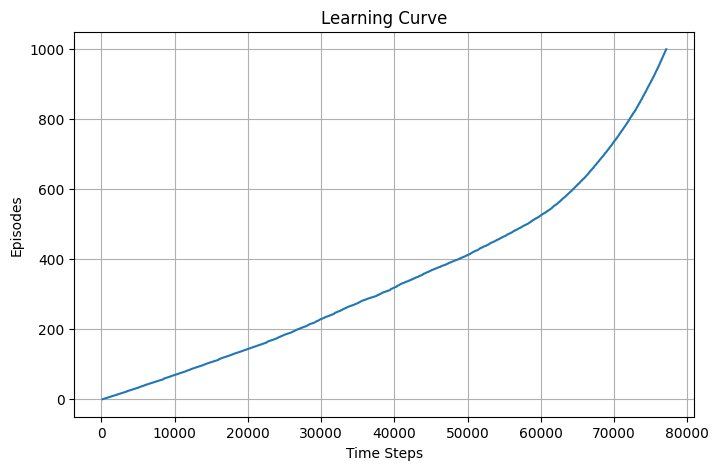

In [32]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

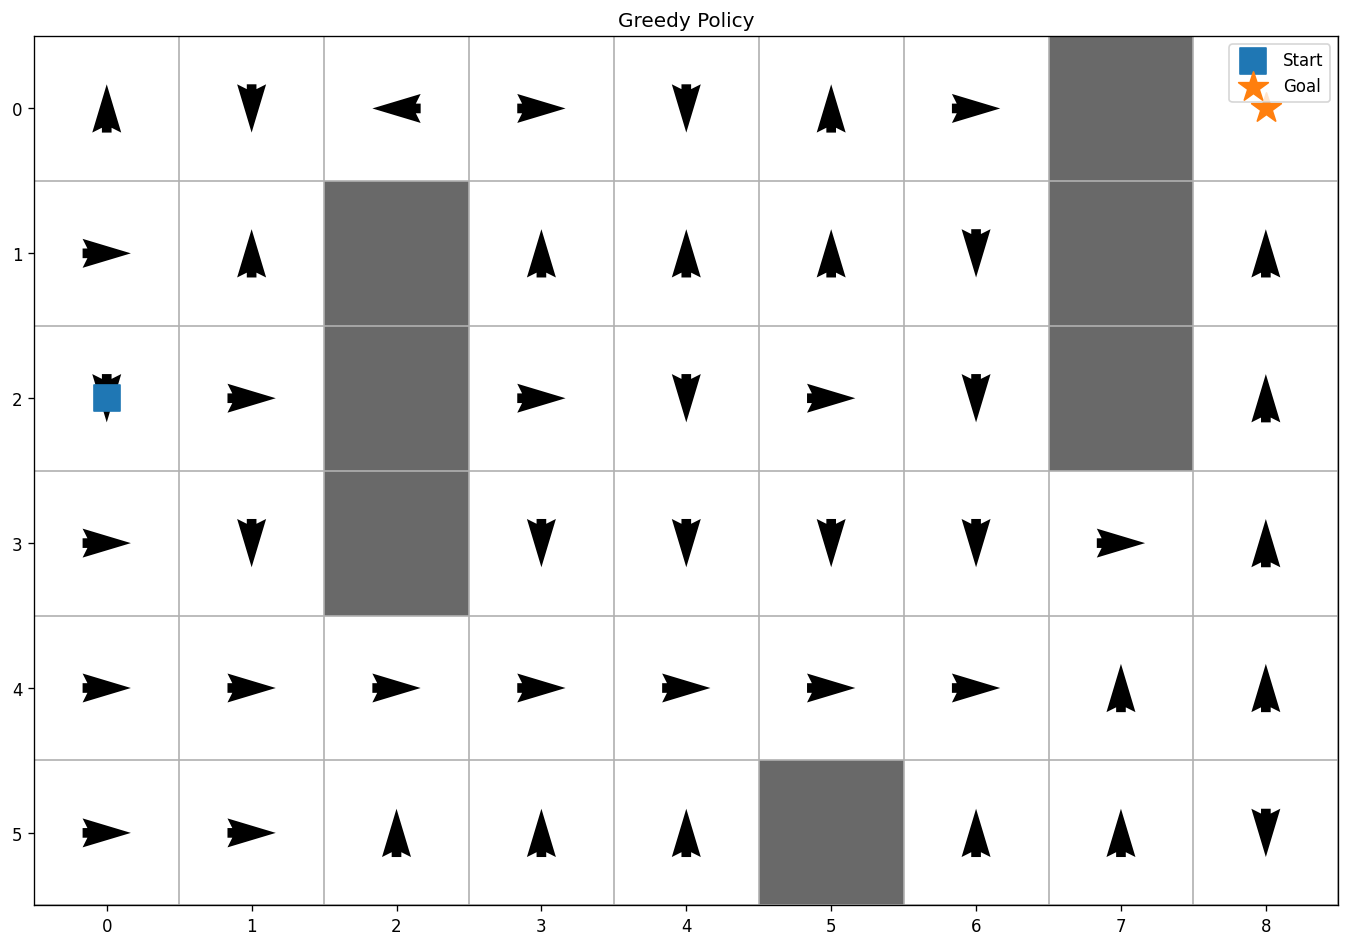

In [33]:
maze_env.plot_policy(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape)
    )

In [38]:
maze_env.animate_episode_with_trail(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape),
    starting_state=(2, 0)
    )

#### Monte-Carlo

In [20]:
def run_monte_carlo_VFA(
    maze_env: GridMazeEnv, 
    gamma: float, alpha: float, 
    epsilon_start: float, epsilon_min: float, epsilon_decay: float,
    num_epochs: int, warmup_epochs: int, max_steps: int,
    state_features_method: Callable,
    ) -> tuple[Q_VFA_Linear, dict]:

    grid_shape = maze_env.grid.shape
    q_hat = Q_VFA_Linear(
        state_features_method(maze_env.goal_position, grid_shape).shape[0], 
        maze_env.action_set.__len__()
        )
    optimizer = torch.optim.SGD(q_hat.parameters(), lr=alpha)
    pbar = tqdm(range(num_epochs), desc="Monte Carlo")
    metrics = {
        "episode_lengths": []
    }

    successes = 0
    for ep_idx in pbar:

        # --- epsilon schedule ---
        if ep_idx < warmup_epochs:
            epsilon = epsilon_start
        else:
            epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** (ep_idx - warmup_epochs)))

        # --- record episode ---
        S = []
        A = []
        R = []

        # --- initial state ---
        S.append(maze_env.reset())

        # --- episode rollout ---
        episode_steps = 0
        for step in range(max_steps):
            # --- select action and step ---
            s = S[-1]
            a = pi_epsilon_greedy(s, q_hat, epsilon, grid_shape, state_features_method)
            r, s_prime, done = maze_env.step(a)

            # --- Reward adjustment for maze ---
            if done:
                r = 1.0 # Goal reward
            else:
                r = -0.01 # Step penalty

            # --- store step ---
            A.append(a)
            R.append(r)
            S.append(s_prime)

            # --- housekeeping ---
            episode_steps = step + 1
            if done:
                successes += 1
                break

        # --- monte-carlo update ---
        losses = [] # aggregate losses and update via batch (instead of individually)
        G = 0.0
        for t in reversed(range(episode_steps)): # calculate loss at each state (every-visit MC)
            G = R[t] + gamma * G

            x_s: torch.Tensor = state_features_method(S[t], grid_shape) # state featuers
            q_sa = q_hat(x_s)[A[t]] # prediction
            target = torch.tensor(G, dtype=q_sa.dtype, device=q_sa.device)
            losses.append((target - q_sa) ** 2) # loss = (target - prediction) ^ 2
            losses.append((G - q_sa) ** 2) 
            
        loss = torch.stack(losses).sum() # Batch update - least squares; NOTE: Using sum instead of mean here
        # to compensate for the significantly lower number of updates. Might compensate for discrepancy and interaction
        # with alpha (lr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # --- update metrics & pbar ---
        metrics["episode_lengths"].append(episode_steps)
        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=step + 1,
            epsilon=f"{epsilon:.3f}",
            G=f"{G:.5f}"
        )
    
    # --- return ---
    return q_hat, metrics

In [21]:
alpha = 1e-3
gamma = 0.99
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999   
num_epochs = 5000
warmup_epochs = 50
max_steps = 500
state_feature_method: Callable = get_state_features_one_hot

q_hat, metrics = run_monte_carlo_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method)

Monte Carlo: 100%|██████████| 5000/5000 [01:00<00:00, 83.32it/s, G=0.75504, epsilon=0.050, steps=14, successes=4932/5000]   


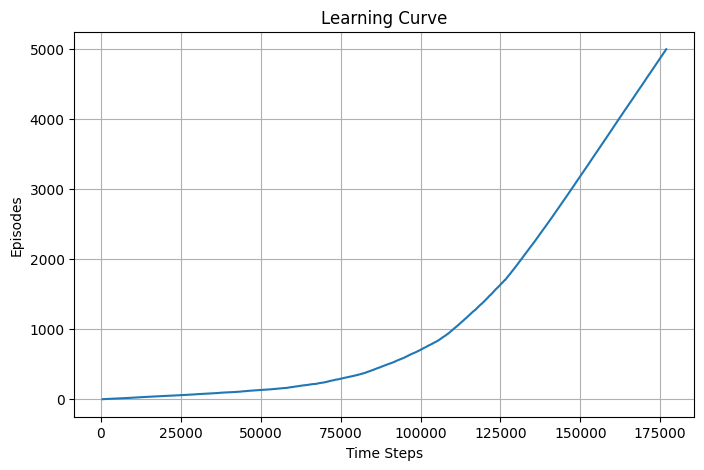

In [22]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

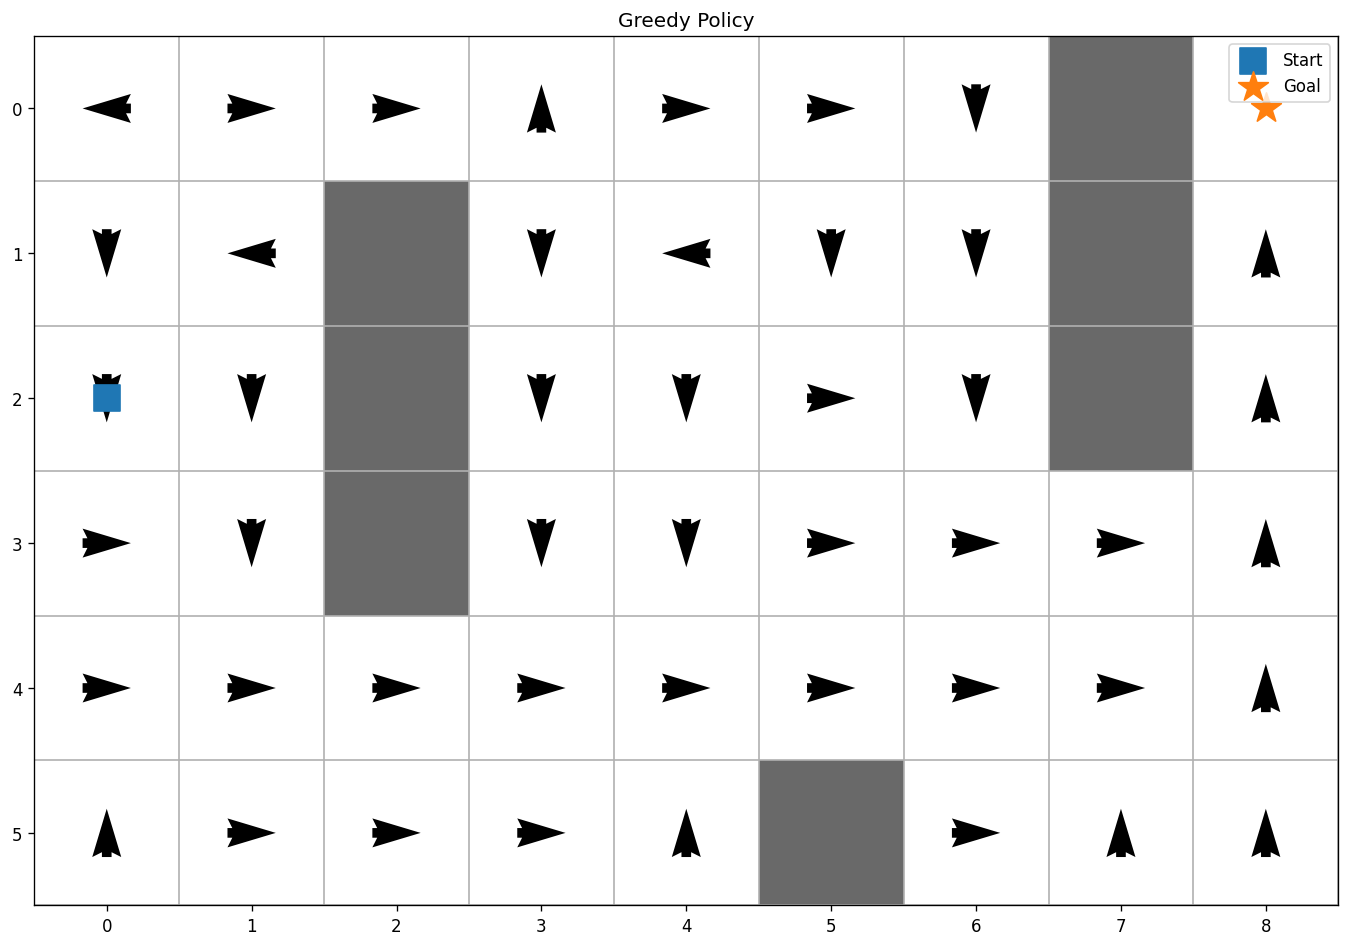

In [23]:
maze_env.plot_policy(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape)
    )

In [24]:
maze_env.animate_episode_with_trail(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape),
    starting_state=(2, 0)
    )